In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import joblib

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")['congestion_level']

category_order = ['Low', 'Medium', 'High', 'Very High']
y_test = pd.Categorical(y_test, categories=category_order, ordered=True)

models = {
    'Logistic Regression': joblib.load('../models/logistic_regression.pkl'),
    'Decision Tree': joblib.load('../models/decision_tree.pkl'),
    'Random Forest': joblib.load('../models/random_forest.pkl'),
    'KNN': joblib.load('../models/knn.pkl')
}

In [2]:
for name, model in models.items():
    preds = model.predict(X_test)
    print(f"\n{'='*55}")
    print(name)
    print('='*55)
    print(classification_report(y_test, preds, labels=category_order))


Logistic Regression
              precision    recall  f1-score   support

         Low       0.86      0.92      0.89      2029
      Medium       0.83      0.74      0.79      2029
        High       0.74      0.81      0.77      2029
   Very High       0.85      0.80      0.82      2028

    accuracy                           0.82      8115
   macro avg       0.82      0.82      0.82      8115
weighted avg       0.82      0.82      0.82      8115


Decision Tree
              precision    recall  f1-score   support

         Low       0.96      0.95      0.96      2029
      Medium       0.89      0.84      0.86      2029
        High       0.77      0.82      0.80      2029
   Very High       0.86      0.86      0.86      2028

    accuracy                           0.87      8115
   macro avg       0.87      0.87      0.87      8115
weighted avg       0.87      0.87      0.87      8115


Random Forest
              precision    recall  f1-score   support

         Low       0.96 

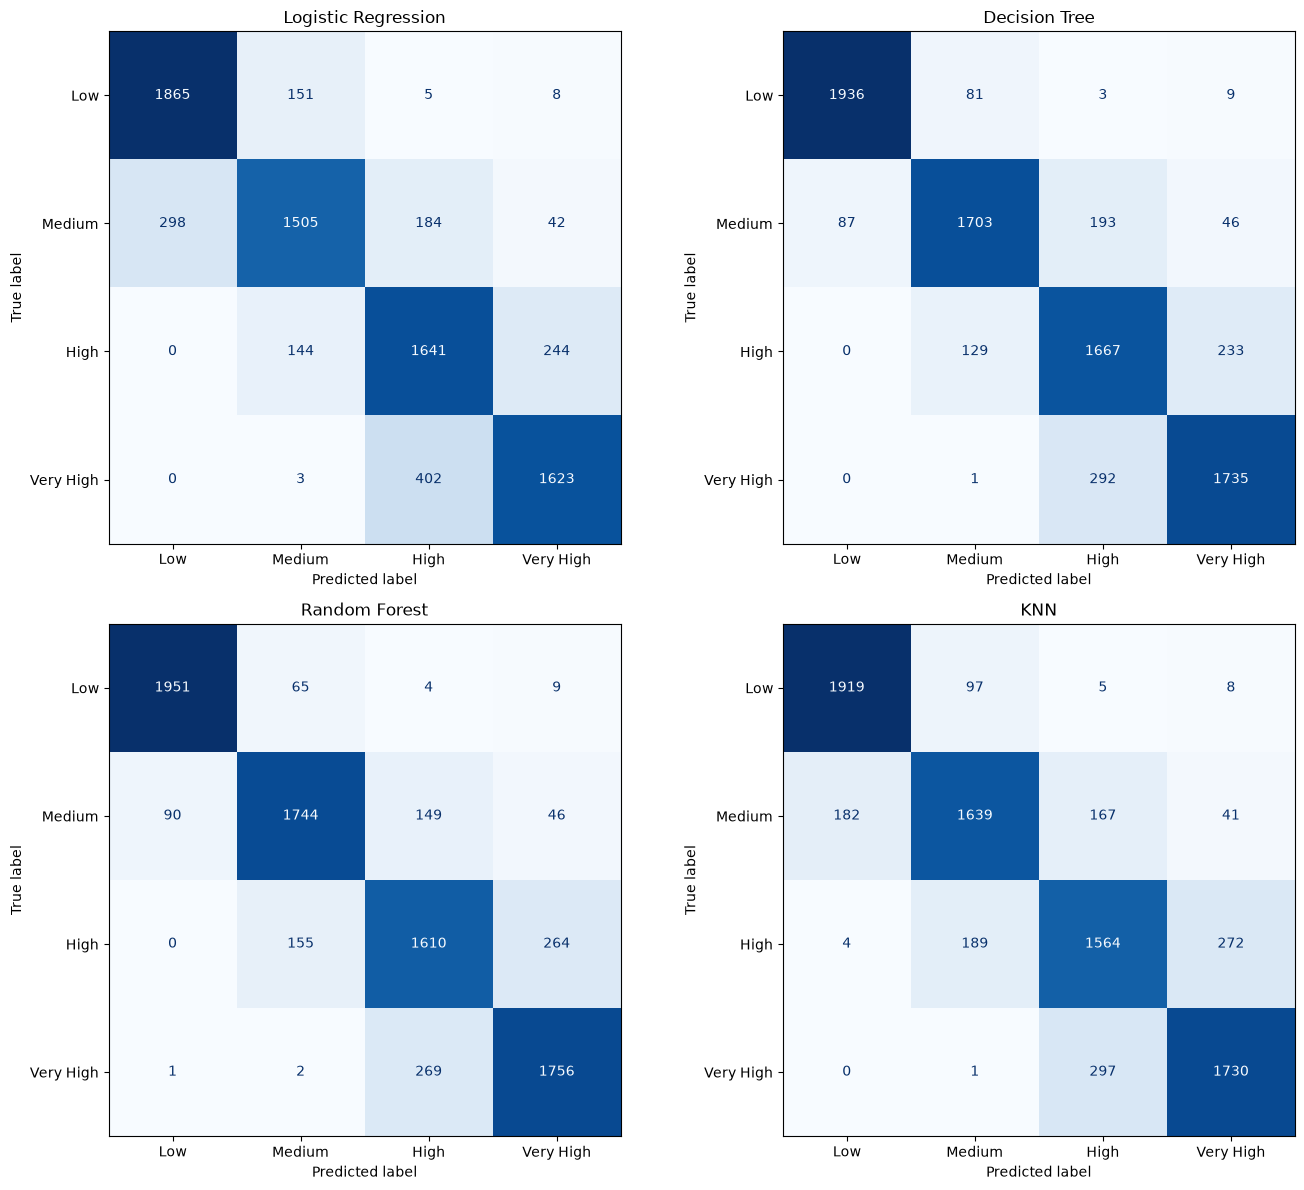

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds, labels=category_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=category_order)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [4]:
summary_rows = []
for name, model in models.items():
    preds = model.predict(X_test)
    precision_per_class = precision_score(y_test, preds, labels=category_order, average=None)
    recall_per_class = recall_score(y_test, preds, labels=category_order, average=None)
    macro_f1 = f1_score(y_test, preds, average='macro')

    summary_rows.append({
        'Model': name,
        'Recall (Very High)': recall_per_class[3],
        'Precision (Low)': precision_per_class[0],
        'Macro F1': macro_f1
    })

pd.DataFrame(summary_rows)

,Model,Recall (Very High),Precision (Low),Macro F1
0,Logistic Regression,0.800296,0.862228,0.817084
1,Decision Tree,0.855523,0.956995,0.868203
2,Random Forest,0.865878,0.955436,0.870111
3,KNN,0.853057,0.911639,0.843884


In [8]:
level_to_num = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}

for name, model in models.items():
    preds = model.predict(X_test)
    y_num = pd.Series(y_test).astype(str).map(level_to_num)
    pred_num = pd.Series(preds).astype(str).map(level_to_num)
    diff = (y_num - pred_num).abs()

    print(f"{name}: {(diff == 0).mean():.1%} exact match | {(diff == 1).mean():.1%} off by 1 level | {(diff >= 2).mean():.1%} off by 2+ levels (the dangerous kind)")

Logistic Regression: 81.7% exact match | 17.5% off by 1 level | 0.7% off by 2+ levels (the dangerous kind)
Decision Tree: 86.8% exact match | 12.5% off by 1 level | 0.7% off by 2+ levels (the dangerous kind)
Random Forest: 87.0% exact match | 12.2% off by 1 level | 0.8% off by 2+ levels (the dangerous kind)
KNN: 84.4% exact match | 14.8% off by 1 level | 0.7% off by 2+ levels (the dangerous kind)


In [7]:
final_model = models['Decision Tree']
joblib.dump(final_model, '../models/final_model.pkl')
print("Final model (Decision Tree) saved as final_model.pkl")

Final model (Decision Tree) saved as final_model.pkl
